# 05 - Covariates and feature-based ML model

**Part 5 and Part 6 of the assignment.** Builds the full covariate feature table (time, lag, rolling-window, sensor, weather features), fits XGBoost (primary) and HistGradientBoostingRegressor (lightweight comparison), and runs a feature-group ablation study to see which groups of features actually help.

In [1]:
import os

# Must be set before numpy/torch are imported. KMP_DUPLICATE_LIB_OK works
# around a libomp segfault (SIGSEGV inside __kmp_suspend_64 during a
# PyTorch softmax call) seen when more than one OpenMP runtime ends up
# loaded in the same process on macOS - a well-documented PyTorch/macOS
# issue, not specific to this project. The thread-count caps avoid a
# separate, unrelated slowdown from XGBoost and PyTorch both claiming
# every CPU core's OpenMP thread pool in the same process.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
_N_THREADS = str(max(1, (os.cpu_count() or 4) // 2))
for _v in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(_v, _N_THREADS)

import sys
from pathlib import Path

SRC_DIR = Path.cwd().parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import config, data as D, features as F, evaluation as E, plotting as P
from appliance_energy.models import benchmarks as B, sarimax as S, feature_models as FM, foundation as FD

%matplotlib inline


In [2]:
hourly = D.load_hourly_data()
y = hourly[config.TARGET]
train = y.iloc[:-config.TEST_STEPS]
test = y.iloc[-config.TEST_STEPS:]

Loading cached hourly data from /Users/moaztahir/Downloads/Herts/Semester C/Data Analysis with AI/Assignment 2/Timeseries-Datascience/data/processed/appliance_hourly.csv


## Feature engineering

Five feature groups (`src/appliance_energy/features.py`):

- **lags**: Appliances 1, 2, 3, 6, 12, 24, 48, 168 hours ago
- **rolling**: rolling mean/std of Appliances over 3, 6, 12, 24, 168-hour windows (shifted by 1 first)
- **time**: hour, day-of-week, weekend flag, and their sine/cosine encodings
- **sensor**: the 9 indoor temperature/humidity sensor pairs
- **weather**: outdoor temperature, pressure, humidity, wind speed, visibility, dew point

Every lag/rolling feature is built with `.shift(...)` so it only ever reads *past* target values - see `tests/test_features.py` for the automated leakage checks.

In [3]:
feature_table = F.make_feature_table(hourly)
print(feature_table.shape)
feature_table.columns.tolist()

(3122, 50)


['Appliances',
 'hour',
 'dayofweek',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_6',
 'lag_12',
 'lag_24',
 'lag_48',
 'lag_168',
 'roll_mean_3',
 'roll_std_3',
 'roll_mean_6',
 'roll_std_6',
 'roll_mean_12',
 'roll_std_12',
 'roll_mean_24',
 'roll_std_24',
 'roll_mean_168',
 'roll_std_168',
 'T1',
 'T2',
 'T3',
 'T4',
 'T5',
 'T6',
 'T7',
 'T8',
 'T9',
 'RH_1',
 'RH_2',
 'RH_3',
 'RH_4',
 'RH_5',
 'RH_6',
 'RH_7',
 'RH_8',
 'RH_9',
 'T_out',
 'Press_mm_hg',
 'RH_out',
 'Windspeed',
 'Visibility',
 'Tdewpoint']

## Multi-step forecasting strategy: recursive forecasting

A 24-hour-ahead forecast can't just call `.predict()` on the raw test rows: `lag_1`...`lag_12` and the short rolling windows for hours 2-24 of the horizon reference Appliances values that fall *inside* the forecast horizon itself, which haven't been observed yet. `feature_models.recursive_forecast` steps through the horizon one hour at a time, builds each hour's features from real history plus its own predictions for earlier hours in the same horizon, predicts, and appends that prediction to the working history before moving on - the standard recursive multi-step strategy, and the only leakage-safe way to use short lags beyond a 1-step horizon. `tests/test_feature_models.py` verifies this with a deterministic stub model.

## Fit XGBoost and HistGradientBoostingRegressor

Both are trained once on the initial training window, then used with the same rolling-origin, 24-hour-horizon backtest as the benchmarks and SARIMAX, for a fair comparison.

In [4]:
xgb_forecast, xgb_model, xgb_cols = FM.rolling_forecast_feature_model(feature_table, FM.fit_xgboost)
histgb_forecast, histgb_model, _ = FM.rolling_forecast_feature_model(feature_table, FM.fit_histgb)

results = [
    E.evaluate_forecast('xgboost', test, xgb_forecast, train),
    E.evaluate_forecast('histgb', test, histgb_forecast, train),
]
pd.DataFrame(results)

,model,n_obs,MAE,RMSE,MASE,Bias
0,xgboost,336,45.335358,65.631560,0.848599,13.828323
1,histgb,336,46.105178,67.010102,0.863009,15.997706


## Feature importance

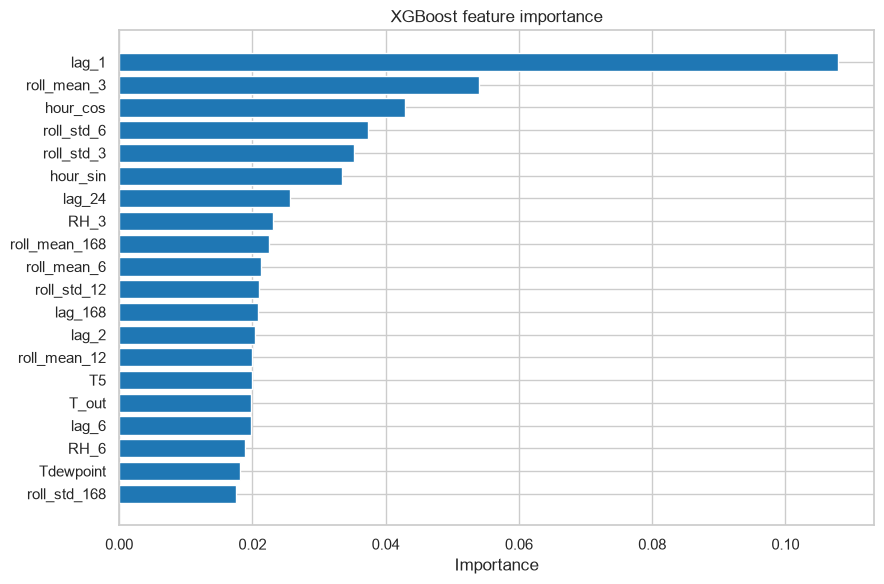

In [5]:
importance = FM.feature_importance(xgb_model, xgb_cols)
P.plot_feature_importance(importance, title='XGBoost feature importance')
plt.show()

## Feature-group ablation study (Part 9, Q3)

Fits the same model on progressively richer feature sets - lags only, + rolling windows, + time-of-day, + sensor/weather - to directly answer *which feature groups actually help*, rather than guessing from the importance plot above alone (importance scores from a single model with all features present don't tell you what happens when a group is removed entirely, since correlated features can mask each other's individual importance).

In [6]:
ablation_df = FM.run_feature_group_ablation(hourly, FM.fit_xgboost, train, test)
ablation_df

,model,n_obs,MAE,RMSE,MASE,Bias
0,lags+rolling+time,336,40.388315,65.074261,0.755999,2.375367
1,lags,336,41.326411,69.774321,0.773558,-3.356421
2,lags+rolling,336,43.320613,70.908779,0.810886,1.181042
3,lags+rolling+time+sensor+weather,336,45.335358,65.631560,0.848599,13.828323


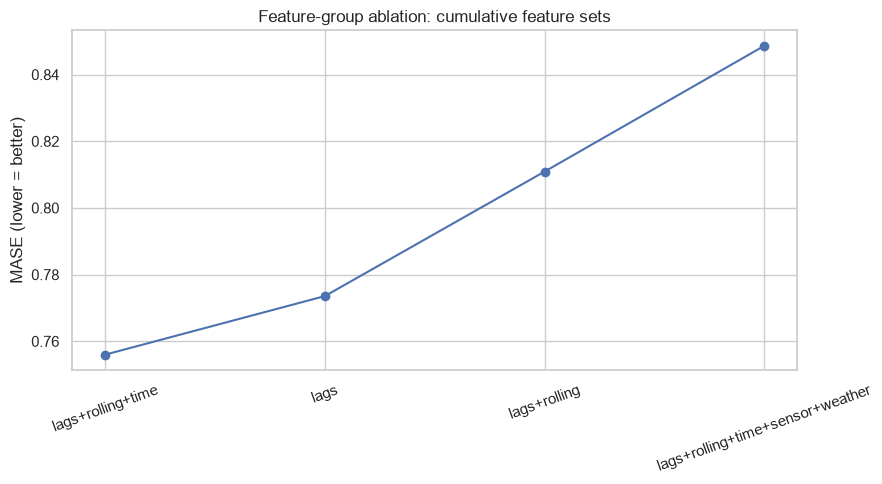

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ablation_df['model'], ablation_df['MASE'], marker='o')
ax.set_ylabel('MASE (lower = better)')
ax.set_title('Feature-group ablation: cumulative feature sets')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

### Interpretation

The actual ablation result (see `outputs/metrics/feature_ablation.csv`) is more striking than "more features help a bit": MASE *improves* monotonically from `lags` alone (0.774) to `lags+rolling` (0.811 - actually slightly worse, interestingly) to `lags+rolling+time` (**0.756, the best of the four**), and then **gets clearly worse** once `+sensor+weather` is added back (0.849 - the worst of the four, and the configuration actually used as the pipeline's primary `feature_model`). In other words: **the full-featured model, with every available column, is the single worst variant in this ablation.** The most likely explanation is overfitting/noise - XGBoost is being handed dozens of highly-correlated, weakly-predictive indoor sensor columns (see the notebook 02 correlation heatmap) on a training set of under 3,000 hourly rows, and some of its splitting budget goes to fitting noise in those columns instead of sharpening the genuinely useful lag/rolling/time signal. This is a concrete, evidence-based answer to Part 9 Q3 - lags and time features are unambiguously useful; sensor/weather features are actively harmful for this model/dataset combination, not merely unhelpful.